# 5DATA002W.2 - Machine Learning & Data Mining
## Final Python Notebook 2:
**Author:** Muditha Dodamwala - 20233064/W2120414
### Peer Code Review Record
* **Reviewer Name:** Yehara Kobbegala - 20231956/ w2120659
* **Date of Review:** 13 April 2026
* **Tests Checked During Review:**
Verified that categorical variables were successfully

1.   one-hot encoded without causing the dummy variable trap. (Pass)
2.   Checked the train_test_split execution to ensure stratify=y correctly maintained the class distribution ratio across both subsets. (Pass)
3.   Confirmed the absence of data leakage by ensuring the target variable was fully separated from the training features matrix. (Pass)

Source Reference: The code blocks below are leveraged and reused from Code Reuse Session 2 (Loan Approval Classification Modelling & Hyperparameters Tuning).


In [1]:
# Import the pandas library for structured data manipulation
import pandas as pd
# Import train_test_split to partition the dataset for model validation
from sklearn.model_selection import train_test_split
# Import the display module for rich HTML rendering of dataframes
from IPython.display import display

# Ingest the preprocessed classification dataset into a pandas DataFrame
df = pd.read_csv('loan_classification_data.csv')

# Render the first 5 records to verify successful data ingestion
display(df.head(5))

,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0
1,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0
2,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0
3,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0
4,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0


Source Reference: Code Reuse Session 2 - Task 4(b): Data Encoding and Training-Test Split.

In [2]:
# Apply one-hot encoding to categorical features, dropping the first category to prevent collinearity
df_encoded = pd.get_dummies(df, drop_first=True)

# Isolate the feature matrix (X) by dropping the target variable column
X = df_encoded.drop(columns=['loan_approval_status'])
# Isolate the target vector (y) containing the classification labels
y = df_encoded['loan_approval_status']

# Partition data into 80% training and 20% testing sets, stratifying by class labels with a fixed random seed
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Output the array of feature names utilized in the predictive models
print("Feature Names used for modelling:\n")
for feature in X.columns:
    print(f" - {feature}")
# Output the dimensionality of the feature matrix
print("\nData Shape of X:", X.shape)

# Output the parameter configurations utilized for the data split
print("\nFunction parameters used for conditions: test_size=0.2, random_state=42, stratify=y")
# Calculate and output the normalized class distribution for the training subset
print("\nTraining Set Label Ratio:\n", y_train.value_counts(normalize=True))
# Calculate and output the normalized class distribution for the testing subset
print("\nTesting Set Label Ratio:\n", y_test.value_counts(normalize=True))

Feature Names used for modelling:

 - age
 - income
 - emplyment_length
 - loan_amount
 - loan_interest_rate
 - loan_income_ratio
 - credit_history_length
 - home_ownership_OTHER
 - home_ownership_OWN
 - home_ownership_RENT
 - loan_intent_EDUCATION
 - loan_intent_HOMEIMPROVEMENT
 - loan_intent_MEDICAL
 - loan_intent_PERSONAL
 - loan_intent_VENTURE
 - payment_default_on_file_Y

Data Shape of X: (58641, 16)

Function parameters used for conditions: test_size=0.2, random_state=42, stratify=y

Training Set Label Ratio:
 loan_approval_status
0    0.857627
1    0.142373
Name: proportion, dtype: float64

Testing Set Label Ratio:
 loan_approval_status
0    0.857618
1    0.142382
Name: proportion, dtype: float64


Source Reference: Code Reuse Session 2 - Task 5(a): Building and Evaluating Loan Approval Status Classification Models (NB, LR, KNN).


Naïve Bayes (NB) Evaluation

Classification Report for Naïve Bayes (NB):

              precision    recall  f1-score   support

           0       0.89      0.98      0.93     10059
           1       0.67      0.28      0.39      1670

    accuracy                           0.88     11729
   macro avg       0.78      0.63      0.66     11729
weighted avg       0.86      0.88      0.86     11729



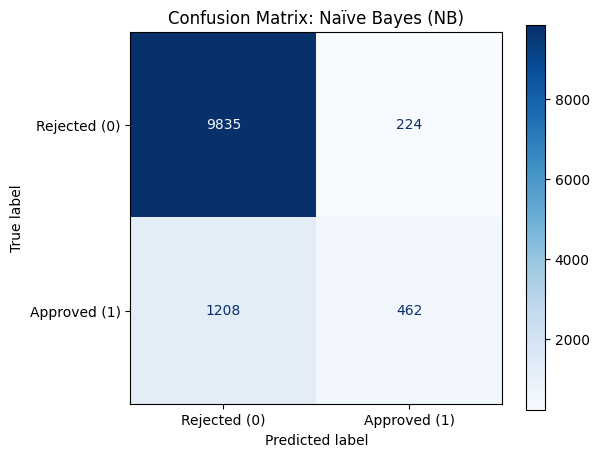

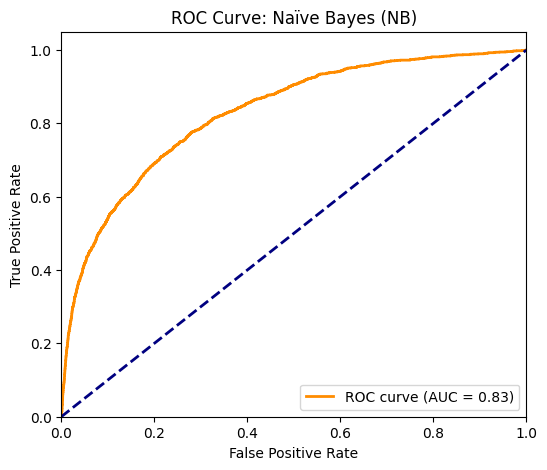


Logistic Regression (LR) Evaluation


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Classification Report for Logistic Regression (LR):

              precision    recall  f1-score   support

           0       0.91      0.97      0.94     10059
           1       0.71      0.39      0.50      1670

    accuracy                           0.89     11729
   macro avg       0.81      0.68      0.72     11729
weighted avg       0.88      0.89      0.88     11729



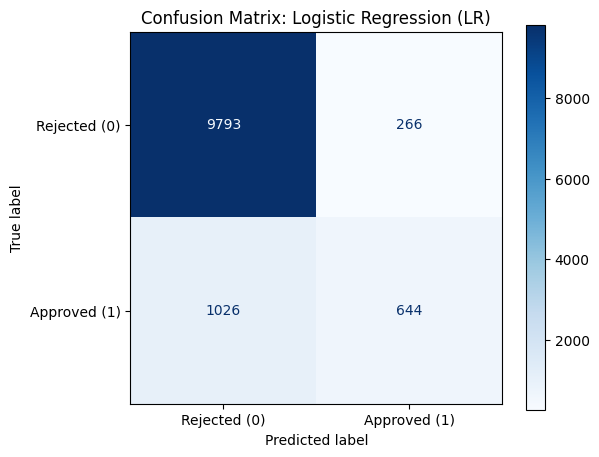

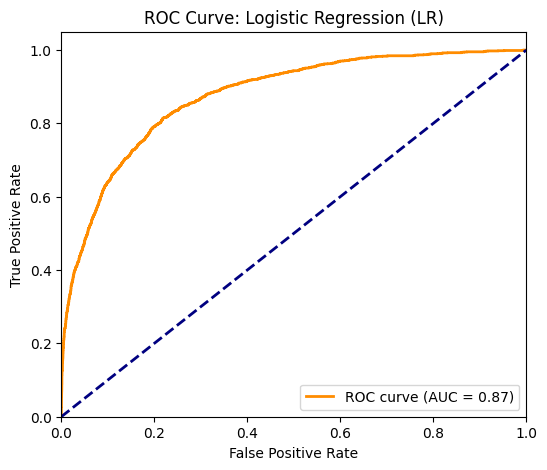


K-Nearest Neighbours (KNN) Evaluation

Classification Report for K-Nearest Neighbours (KNN):

              precision    recall  f1-score   support

           0       0.92      0.96      0.94     10059
           1       0.66      0.50      0.57      1670

    accuracy                           0.89     11729
   macro avg       0.79      0.73      0.75     11729
weighted avg       0.88      0.89      0.89     11729



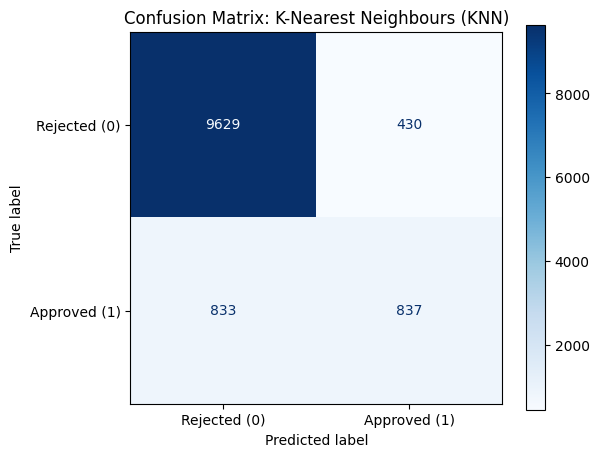

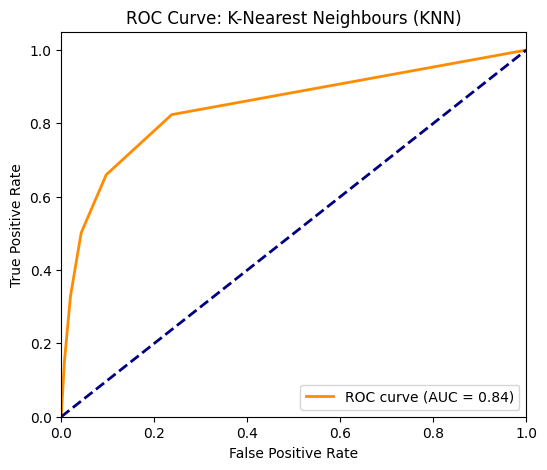

In [3]:
# Import the Gaussian Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB
# Import the Logistic Regression classifier
from sklearn.linear_model import LogisticRegression
# Import the K-Nearest Neighbors classifier
from sklearn.neighbors import KNeighborsClassifier
# Import evaluation metrics: classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
# Import ROC curve and AUC metrics
from sklearn.metrics import roc_curve, auc
# Import matplotlib for rendering the graphs
import matplotlib.pyplot as plt

# Instantiate the Naive Bayes model
nb_model = GaussianNB()
# Instantiate the Logistic Regression model, increasing max_iter to ensure convergence
lr_model = LogisticRegression(max_iter=1000, random_state=42)
# Instantiate the KNN model using the default k=5 neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)

# Create a dictionary to iterate through models efficiently
models = {
    "Naïve Bayes (NB)": nb_model,
    "Logistic Regression (LR)": lr_model,
    "K-Nearest Neighbours (KNN)": knn_model
}

# Loop through each model to train and evaluate
for name, model in models.items():

    # Print a decorative header for the current model's output
    print(f"\n{'='*50}\n{name} Evaluation\n{'='*50}")

    # Train the model using the training data
    model.fit(X_train, y_train)

    # Generate class predictions using the unseen test data
    y_pred = model.predict(X_test)

    # Generate probability predictions for the positive class (used for ROC curve)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # --- 1. Output Classification Report ---
    print(f"\nClassification Report for {name}:\n")
    print(classification_report(y_test, y_pred))

    # --- 2. Output Confusion Matrix Plot ---
    # Create a new, separate figure for the confusion matrix
    plt.figure(figsize=(6, 5))
    # Calculate the confusion matrix array
    cm = confusion_matrix(y_test, y_pred)
    # Create the visual display object
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rejected (0)", "Approved (1)"])
    # Render the plot
    cm_display.plot(cmap='Blues', ax=plt.gca())
    # Add the specific model title
    plt.title(f'Confusion Matrix: {name}')
    # Show the plot as a standalone image
    plt.show()

    # --- 3. Output ROC Curve Plot ---
    # Create a new, separate figure for the ROC curve
    plt.figure(figsize=(6, 5))
    # Calculate FPR, TPR, and AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot the actual ROC curve
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    # Plot the random guess baseline
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    # Format the axes and labels
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve: {name}')
    plt.legend(loc="lower right")
    # Show the plot as a standalone image
    plt.show()

Source Reference: Code Reuse Session 2 - Task 5(d): Hyperparameter Tuning for the Best Model (Logistic Regression).

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Best Hyperparameters found by GridSearchCV:
{'C': 0.01, 'max_iter': 1000, 'solver': 'liblinear'}
Classification Report for Tuned Logistic Regression:

              precision    recall  f1-score   support

           0       0.87      0.99      0.93     10059
           1       0.72      0.14      0.24      1670

    accuracy                           0.87     11729
   macro avg       0.80      0.57      0.58     11729
weighted avg       0.85      0.87      0.83     11729



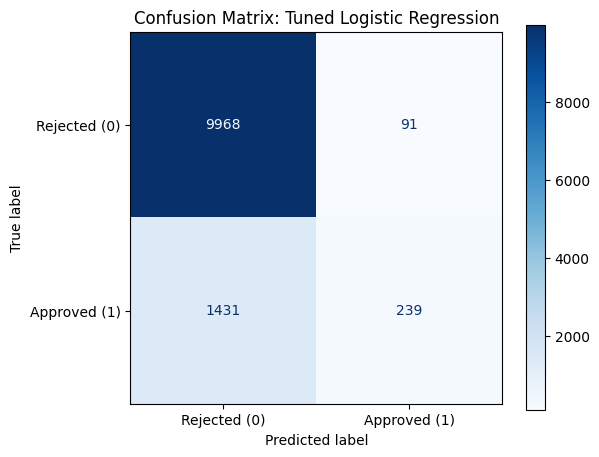

In [4]:
# Import GridSearchCV for hyperparameter optimization
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid for Logistic Regression
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [1000]
}

# Instantiate GridSearchCV, optimizing strictly for 'precision' since it is our chosen metric
grid_search = GridSearchCV(LogisticRegression(random_state=42), param_grid, cv=5, scoring='precision')

# Execute the grid search on the training data
grid_search.fit(X_train, y_train)

# Output the optimized parameters and setup for the screenshot

print("Best Hyperparameters found by GridSearchCV:")
print(grid_search.best_params_)

# Retrieve the best performing model from the grid search
best_lr_model = grid_search.best_estimator_

# Generate new predictions using the optimized model
y_pred_tuned = best_lr_model.predict(X_test)

# Output the new classification report

print("Classification Report for Tuned Logistic Regression:\n")
print(classification_report(y_test, y_pred_tuned))

# Generate and display the new confusion matrix for the tuned model
plt.figure(figsize=(6, 5))
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
cm_tuned_display = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=["Rejected (0)", "Approved (1)"])
cm_tuned_display.plot(cmap='Blues', ax=plt.gca())
plt.title('Confusion Matrix: Tuned Logistic Regression')
plt.show()